# 🔬 Notebook 5: Ingeniería de Features Avanzada

## Propósito

Este notebook amplía el conjunto de features del baseline (11 variables) con 14 nuevas características que capturan tres dimensiones clave del problema de estrategia en Fórmula 1:

1. **Posición competitiva en pista**: gap real al coche de delante y de detrás, ventana DRS.
2. **Historial de la carrera**: paradas ya realizadas, vueltas en el stint actual, vueltas restantes.
3. **Degradación avanzada**: tendencia de los tiempos de vuelta, delta respecto al mejor propio y rendimiento relativo al resto del campo.

## Cambios respecto a versiones anteriores del notebook

- El cálculo de los **gaps entre coches** se realiza ahora correctamente a partir del **tiempo acumulado de carrera** (suma de los tiempos de vuelta por piloto), no como diferencia entre los tiempos de vuelta de coches consecutivos. Este cambio corrige el error metodológico identificado en una primera versión del notebook y unifica en un solo paso lo que antes se distribuía entre los notebooks 5 y 7.
- Al final del notebook se **persisten en disco los datasets resultantes** con las 25 features, lo que permite reutilizarlos en los notebooks 8 (validación por grupos) y 9 (análisis SHAP) sin necesidad de reejecutar toda la cadena de ingeniería de features.

## Estructura

1. Imports y carga del dataset base
2. Cálculo correcto de gaps entre coches
   - 2.1 Reconstrucción del tiempo acumulado de carrera
   - 2.2 Cálculo del gap delante/detrás y ventana DRS
   - 2.3 Validación
3. Historial de paradas y stint
4. Degradación avanzada
5. Rendimiento relativo al campo
6. Reconstrucción de datasets con las 25 features
7. Preparación de X/y y normalización
8. Reentrenamiento de modelos con hiperparámetros óptimos (Nb4)
9. Evaluación — clasificación
10. Evaluación — regresión
11. Comparativa 11 vs 25 features
12. Importancia de variables actualizada
13. Persistencia de los datasets con 25 features
14. Resumen final


## 1. Imports y carga de datos base

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, pickle, json, os
from pathlib import Path

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42

print('✅ Imports completados')


✅ Imports completados


In [8]:
# Carga del dataset base (procesado en Nb1, con 11 features originales y target_parada)
df = pd.read_csv('./datasets/dataset_clasificacion.csv')

print(f'Dataset base: {df.shape}')
print(f'Columnas: {list(df.columns)}')
print(f'Temporadas: {sorted(df["Season"].unique())}')
print(f'Carreras: {df.groupby(["Season","Round"]).ngroups}')
print(f'Pilotos: {df["Driver"].nunique()}')


Dataset base: (92991, 18)
Columnas: ['Season', 'Round', 'EventName', 'EventDate', 'Driver', 'LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber', 'IsHard', 'IsMedium', 'IsSoft', 'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator', 'target_parada', 'StopLapNumber']
Temporadas: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Carreras: 90
Pilotos: 31


## 2. Cálculo correcto de gaps entre coches

El gap real entre dos coches en una vuelta dada **no** se obtiene restando sus tiempos de vuelta (esa magnitud mide solo la diferencia de ritmo en esa vuelta, no la separación física). El gap correcto se calcula a partir del **tiempo acumulado de carrera** de cada coche: si dos coches consecutivos cruzan la línea de meta de la misma vuelta en momentos diferentes, la diferencia entre esos momentos *es* el gap real.

### 2.1 Reconstrucción del tiempo acumulado de carrera

In [9]:
# Cálculo vectorizado del tiempo acumulado: cumsum del tiempo de vuelta por (Season, Round, Driver)
# Esta forma vectorizada conserva todas las columnas del DataFrame original (no usa groupby.apply,
# que en pandas reciente excluye las claves del groupby del DataFrame resultante).

if 'Time' in df.columns and df['Time'].notna().sum() > len(df) * 0.8:
    print('Se utiliza la columna Time existente del dataset')
    df['RaceTime'] = pd.to_numeric(df['Time'], errors='coerce')
else:
    print('Reconstruyendo el tiempo acumulado a partir de los tiempos de vuelta...')
    df = df.sort_values(['Season', 'Round', 'Driver', 'LapNumber']).reset_index(drop=True)
    df['RaceTime'] = df.groupby(['Season', 'Round', 'Driver'])['LapTime_seconds'].cumsum()

print(f'\n✅ Tiempo acumulado disponible')
print(f'  RaceTime: min={df["RaceTime"].min():.1f}s, '
      f'max={df["RaceTime"].max():.1f}s, media={df["RaceTime"].mean():.1f}s')

# Comprobación de coherencia: el tiempo acumulado debe crecer monótonamente por piloto
muestra = df[(df['Season'] == df['Season'].iloc[0]) &
             (df['Round'] == df['Round'].iloc[0])].groupby('Driver')
monotono = all(g['RaceTime'].is_monotonic_increasing
               for _, g in muestra if len(g) > 1)
print(f'  Comprobación de monotonía (tiempo siempre creciente): '
      f'{"✓ correcta" if monotono else "✗ REVISAR"}')


Reconstruyendo el tiempo acumulado a partir de los tiempos de vuelta...

✅ Tiempo acumulado disponible
  RaceTime: min=72.0s, max=8655.8s, media=2700.4s
  Comprobación de monotonía (tiempo siempre creciente): ✓ correcta


### 2.2 Cálculo del gap al coche de delante y al de detrás

In [10]:
def calcular_gaps_correcto(df_carrera):
    '''Calcula el gap real entre coches usando el tiempo acumulado de carrera.'''
    dc = df_carrera.copy()
    dc['GapAhead'] = np.nan
    dc['GapBehind'] = np.nan

    for lap_num in dc['LapNumber'].unique():
        mask = dc['LapNumber'] == lap_num
        lap_data = dc[mask].sort_values('Position')

        # Mapa posición -> tiempo acumulado en esta vuelta
        pos_to_time = dict(zip(lap_data['Position'], lap_data['RaceTime']))

        for idx, row in lap_data.iterrows():
            pos = row['Position']
            rt = row['RaceTime']
            if pd.isna(rt):
                continue
            # Gap al coche de delante (posición - 1): el de delante tiene menos tiempo
            t_ahead = pos_to_time.get(pos - 1)
            if t_ahead is not None and pd.notna(t_ahead):
                dc.loc[idx, 'GapAhead'] = rt - t_ahead
            # Gap al coche de detrás (posición + 1): el de detrás tiene más tiempo
            t_behind = pos_to_time.get(pos + 1)
            if t_behind is not None and pd.notna(t_behind):
                dc.loc[idx, 'GapBehind'] = t_behind - rt
    return dc

print('Recalculando gaps correctamente (puede tardar unos minutos)...')

# Iteración explícita por carrera (en lugar de groupby.apply, que en pandas reciente
# excluye las columnas Season y Round del DataFrame resultante).
partes = []
n_carreras = df.groupby(['Season', 'Round']).ngroups
for i, ((season, round_), grupo) in enumerate(df.groupby(['Season', 'Round'], sort=False), 1):
    partes.append(calcular_gaps_correcto(grupo))
    if i % 20 == 0:
        print(f'  Carreras procesadas: {i}/{n_carreras}')

df = pd.concat(partes, ignore_index=True)

# IsInDRSWindow: el coche de delante está a menos de 1 segundo
df['IsInDRSWindow'] = (df['GapAhead'] < 1.0).astype(int)

# Rellenar NaN: el líder no tiene coche delante; el último no tiene coche detrás
df['GapAhead'] = df['GapAhead'].fillna(df['GapAhead'].median())
df['GapBehind'] = df['GapBehind'].fillna(df['GapBehind'].median())

print('✅ Gaps recalculados correctamente')


Recalculando gaps correctamente (puede tardar unos minutos)...
  Carreras procesadas: 20/90
  Carreras procesadas: 40/90
  Carreras procesadas: 60/90
  Carreras procesadas: 80/90
✅ Gaps recalculados correctamente


### 2.3 Validación de los gaps calculados

Comprobamos que las distribuciones obtenidas son coherentes con la realidad de una carrera: gaps típicamente positivos, mediana de pocos segundos, una fracción reducida de vueltas en ventana DRS (gap < 1 s).

In [11]:
print('Estadísticos de las variables de gap recalculadas:')
print(df[['GapAhead', 'GapBehind']].describe().round(2).to_string())

print(f'\nVueltas en ventana DRS (gap < 1 s): {df["IsInDRSWindow"].mean():.1%}')

# Comprobaciones de coherencia
print(f'\nComprobaciones de coherencia:')
gap_ahead_neg = (df['GapAhead'] < 0).mean()
print(f'  GapAhead negativos: {gap_ahead_neg:.1%} '
      f'(esperado: bajo; un valor negativo indica solapamiento por adelantamiento '
      f'reciente o doblaje)')
mediana_ga = df['GapAhead'].median()
print(f'  Mediana de GapAhead: {mediana_ga:.2f}s '
      f'(esperado: unos pocos segundos entre coches consecutivos)')
pct_grande = (df['GapAhead'] > 60).mean()
print(f'  GapAhead > 60s: {pct_grande:.1%} '
      f'(pueden corresponder a coches doblados)')


Estadísticos de las variables de gap recalculadas:
       GapAhead  GapBehind
count  92991.00   92991.00
mean       6.90       6.90
std      118.98     118.98
min    -2237.99   -2237.99
25%        0.96       0.96
50%        2.39       2.39
75%        5.90       5.90
max     2301.03    2301.03

Vueltas en ventana DRS (gap < 1 s): 25.9%

Comprobaciones de coherencia:
  GapAhead negativos: 6.6% (esperado: bajo; un valor negativo indica solapamiento por adelantamiento reciente o doblaje)
  Mediana de GapAhead: 2.39s (esperado: unos pocos segundos entre coches consecutivos)
  GapAhead > 60s: 5.1% (pueden corresponder a coches doblados)


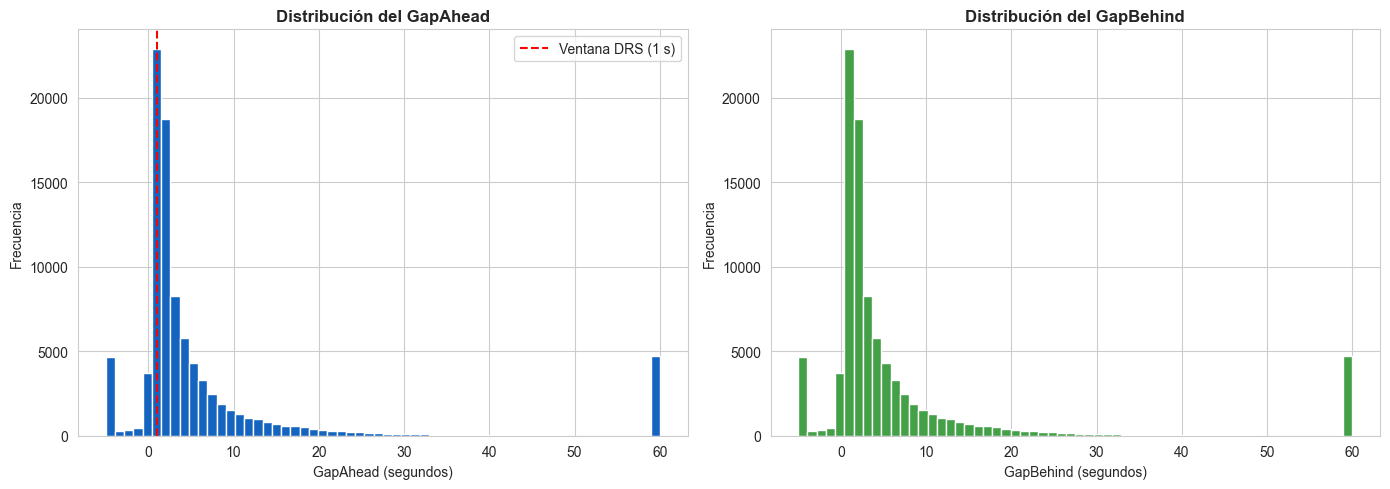

In [12]:
# Histogramas de los nuevos gaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ga_plot = df['GapAhead'].clip(-5, 60)
axes[0].hist(ga_plot, bins=60, color='#1565C0', edgecolor='white')
axes[0].axvline(1.0, color='red', linestyle='--', label='Ventana DRS (1 s)')
axes[0].set_xlabel('GapAhead (segundos)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del GapAhead', fontweight='bold')
axes[0].legend()

gb_plot = df['GapBehind'].clip(-5, 60)
axes[1].hist(gb_plot, bins=60, color='#43A047', edgecolor='white')
axes[1].set_xlabel('GapBehind (segundos)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución del GapBehind', fontweight='bold')

plt.tight_layout()
os.makedirs('./datasets/prepared', exist_ok=True)
plt.savefig('./datasets/prepared/fig_gaps_corregidos.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Historial de paradas y stint

In [13]:
def calcular_historial_paradas(group):
    '''Paradas ya realizadas, vueltas en stint actual y vueltas restantes.'''
    g = group.sort_values('LapNumber').copy()

    # Paradas acumuladas ANTES de esta vuelta (shift para no contar la actual)
    g['NumStopsDone'] = g['target_parada'].shift(1, fill_value=0).cumsum()

    # Vueltas en el stint actual (reinicia con cada parada)
    stint_id = g['NumStopsDone'].diff().fillna(0).ne(0).cumsum()
    g['LapsInCurrentStint'] = g.groupby(stint_id).cumcount() + 1

    # Vueltas restantes
    total = g['TotalLaps'].iloc[0] if 'TotalLaps' in g.columns else g['LapNumber'].max()
    g['RemainingLaps'] = total - g['LapNumber']
    g['RemainingLapsPct'] = g['RemainingLaps'] / total

    return g

print('Calculando historial de paradas y carrera restante...')
partes = []
for _, grupo in df.groupby(['Season', 'Round', 'Driver'], sort=False):
    partes.append(calcular_historial_paradas(grupo))
df = pd.concat(partes, ignore_index=True)

print(f'✅ Historial calculado')
print(f'  NumStopsDone: {df["NumStopsDone"].value_counts().sort_index().to_dict()}')
print(f'  RemainingLaps: media={df["RemainingLaps"].mean():.1f}')


Calculando historial de paradas y carrera restante...
✅ Historial calculado
  NumStopsDone: {0: 31795, 1: 38534, 2: 18204, 3: 3736, 4: 669, 5: 51, 6: 2}
  RemainingLaps: media=28.7


## 4. Degradación avanzada

Tres variables que enriquecen el indicador de degradación básico:

- **DegradationTrend**: pendiente de los tiempos de vuelta en una ventana móvil de 5 vueltas (positivo = empeorando, negativo = mejorando).
- **DegradationAccel**: cambio en la pendiente (derivada segunda, indica si la degradación se está acelerando).
- **DeltaVsBestLap**: diferencia entre la vuelta actual y el mejor tiempo del piloto hasta ahora.
- **AvgTime_CurrentStint**: media de tiempos en el stint actual, indicador del rendimiento con los neumáticos en uso.

In [14]:
def calcular_degradacion_avanzada(group):
    g = group.sort_values('LapNumber').copy()
    lt = g['LapTime_seconds']

    # Tendencia: pendiente de tiempos en últimas 5 vueltas (rolling slope)
    def rolling_slope(series, window=5):
        slopes = []
        for i in range(len(series)):
            if i < window - 1:
                slopes.append(np.nan)
            else:
                y = series.iloc[i-window+1:i+1].values
                if np.any(np.isnan(y)):
                    slopes.append(np.nan)
                else:
                    slopes.append(np.polyfit(np.arange(window), y, 1)[0])
        return slopes

    g['DegradationTrend'] = rolling_slope(lt, window=5)
    g['DegradationAccel'] = g['DegradationTrend'].diff()
    g['DeltaVsBestLap'] = lt - lt.expanding().min()
    g['AvgTime_CurrentStint'] = g.groupby('StintNumber')['LapTime_seconds'].transform(
        lambda x: x.expanding().mean())
    return g

print('Calculando degradación avanzada...')
partes = []
for _, grupo in df.groupby(['Season', 'Round', 'Driver'], sort=False):
    partes.append(calcular_degradacion_avanzada(grupo))
df = pd.concat(partes, ignore_index=True)

# Rellenar NaN iniciales (primeras vueltas sin ventana suficiente)
for col in ['DegradationTrend', 'DegradationAccel', 'DeltaVsBestLap', 'AvgTime_CurrentStint']:
    df[col] = df[col].fillna(0)

print(f'✅ Degradación avanzada calculada')
print(f'  DegradationTrend: media={df["DegradationTrend"].mean():.4f}')
print(f'  DeltaVsBestLap: media={df["DeltaVsBestLap"].mean():.2f}s')


Calculando degradación avanzada...
✅ Degradación avanzada calculada
  DegradationTrend: media=-0.2354
  DeltaVsBestLap: media=2.52s


## 5. Rendimiento relativo al campo

Variables que sitúan al piloto respecto al resto del campo en cada vuelta:

- **DeltaVsFieldMean**: diferencia entre el tiempo del piloto y la media de la vuelta.
- **ZScoreVsField**: la misma diferencia normalizada por la desviación típica de la vuelta.
- **PositionNormalized**: posición en pista normalizada al rango [0, 1] (0 = líder, 1 = último).

In [15]:
def calcular_rendimiento_relativo(df_carrera):
    dc = df_carrera.copy()

    lap_means = dc.groupby('LapNumber')['LapTime_seconds'].transform('mean')
    lap_stds = dc.groupby('LapNumber')['LapTime_seconds'].transform('std')

    dc['DeltaVsFieldMean'] = dc['LapTime_seconds'] - lap_means
    dc['ZScoreVsField'] = np.where(lap_stds > 0,
        (dc['LapTime_seconds'] - lap_means) / lap_stds, 0)
    n_drivers = dc.groupby('LapNumber')['Driver'].transform('count')
    dc['PositionNormalized'] = (dc['Position'] - 1) / (n_drivers - 1).clip(lower=1)

    return dc

print('Calculando rendimiento relativo al campo...')
partes = []
for _, grupo in df.groupby(['Season', 'Round'], sort=False):
    partes.append(calcular_rendimiento_relativo(grupo))
df = pd.concat(partes, ignore_index=True)

# Rellenar NaN
for col in ['DeltaVsFieldMean', 'ZScoreVsField', 'PositionNormalized']:
    df[col] = df[col].fillna(0)

print(f'✅ Rendimiento relativo calculado')
print(f'  DeltaVsFieldMean: media={df["DeltaVsFieldMean"].mean():.3f}s')
print(f'  ZScoreVsField: media={df["ZScoreVsField"].mean():.3f}')


Calculando rendimiento relativo al campo...
✅ Rendimiento relativo calculado
  DeltaVsFieldMean: media=0.000s
  ZScoreVsField: media=-0.000


## 6. Definición del conjunto de features y reconstrucción de datasets

In [16]:
# Definición del conjunto completo de features
FEATURES_ORIGINAL = [
    'LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber',
    'IsHard', 'IsMedium', 'IsSoft',
    'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator',
]

FEATURES_NUEVAS = [
    # Gaps (calculados correctamente)
    'GapAhead', 'GapBehind', 'IsInDRSWindow',
    # Historial de paradas
    'NumStopsDone', 'LapsInCurrentStint', 'RemainingLaps', 'RemainingLapsPct',
    # Degradación avanzada
    'DegradationTrend', 'DegradationAccel', 'DeltaVsBestLap', 'AvgTime_CurrentStint',
    # Rendimiento relativo
    'DeltaVsFieldMean', 'ZScoreVsField', 'PositionNormalized',
]

FEATURES_ALL = FEATURES_ORIGINAL + FEATURES_NUEVAS

# Verificación de disponibilidad
features_disponibles = [f for f in FEATURES_ALL if f in df.columns]
features_faltantes = [f for f in FEATURES_ALL if f not in df.columns]

print(f'Features originales: {len(FEATURES_ORIGINAL)}')
print(f'Features nuevas: {len(FEATURES_NUEVAS)}')
print(f'Total disponibles: {len(features_disponibles)}')
if features_faltantes:
    print(f'⚠️ Faltantes: {features_faltantes}')
else:
    print(f'✅ Todas las features presentes')

print(f'\nFeatures nuevas añadidas:')
for f in FEATURES_NUEVAS:
    if f in df.columns:
        print(f'  ✓ {f:25s} → media={df[f].mean():.3f}, nulls={df[f].isnull().sum()}')


Features originales: 11
Features nuevas: 14
Total disponibles: 25
✅ Todas las features presentes

Features nuevas añadidas:
  ✓ GapAhead                  → media=6.903, nulls=0
  ✓ GapBehind                 → media=6.903, nulls=0
  ✓ IsInDRSWindow             → media=0.259, nulls=0
  ✓ NumStopsDone              → media=0.958, nulls=0
  ✓ LapsInCurrentStint        → media=14.061, nulls=0
  ✓ RemainingLaps             → media=28.676, nulls=0
  ✓ RemainingLapsPct          → media=0.481, nulls=0
  ✓ DegradationTrend          → media=-0.235, nulls=0
  ✓ DegradationAccel          → media=0.140, nulls=0
  ✓ DeltaVsBestLap            → media=2.520, nulls=0
  ✓ AvgTime_CurrentStint      → media=94.044, nulls=0
  ✓ DeltaVsFieldMean          → media=0.000, nulls=0
  ✓ ZScoreVsField             → media=-0.000, nulls=0
  ✓ PositionNormalized        → media=0.524, nulls=0


In [17]:
# Construcción del target de regresión: LapsUntilNextStop
df_sorted = df.sort_values(['Season', 'Round', 'Driver', 'LapNumber']).copy()

def calcular_laps_until_stop(group):
    g = group.copy()
    stop_laps = g[g['target_parada'] == 1]['LapNumber'].values
    laps_until = []
    for _, row in g.iterrows():
        lap = row['LapNumber']
        future_stops = stop_laps[stop_laps >= lap]
        laps_until.append(future_stops[0] - lap if len(future_stops) > 0 else -1)
    g['LapsUntilNextStop'] = laps_until
    return g

print('Calculando LapsUntilNextStop...')
partes = []
for _, grupo in df_sorted.groupby(['Season', 'Round', 'Driver'], sort=False):
    partes.append(calcular_laps_until_stop(grupo))
df_with_target = pd.concat(partes, ignore_index=True)

# Datasets por tarea
# Clasificación: todas las vueltas
df_clasif = df_with_target.copy()
# Regresión: solo vueltas con parada futura
df_regres = df_with_target[df_with_target['LapsUntilNextStop'] >= 0].copy()

# División temporal 80/20 (orden cronológico por EventDate)
df_clasif = df_clasif.sort_values('EventDate').reset_index(drop=True)
df_regres = df_regres.sort_values('EventDate').reset_index(drop=True)

n_c = int(len(df_clasif) * 0.8)
n_r = int(len(df_regres) * 0.8)

train_c = df_clasif.iloc[:n_c]
test_c = df_clasif.iloc[n_c:]
train_r = df_regres.iloc[:n_r]
test_r = df_regres.iloc[n_r:]

print(f'\nDatasets reconstruidos:')
print(f'  Clasificación: train={len(train_c):,} | test={len(test_c):,}')
print(f'  Regresión: train={len(train_r):,} | test={len(test_r):,}')
print(f'  Features: {len(features_disponibles)} ({len(FEATURES_ORIGINAL)} originales + {len(FEATURES_NUEVAS)} nuevas)')


Calculando LapsUntilNextStop...

Datasets reconstruidos:
  Clasificación: train=74,392 | test=18,599
  Regresión: train=42,691 | test=10,673
  Features: 25 (11 originales + 14 nuevas)


## 7. Preparación de X/y y normalización

In [18]:
# Construcción de X, y
X_train_c = train_c[features_disponibles].copy()
y_train_c = train_c['target_parada'].copy()
X_test_c = test_c[features_disponibles].copy()
y_test_c = test_c['target_parada'].copy()

X_train_r = train_r[features_disponibles].copy()
y_train_r = train_r['LapsUntilNextStop'].copy()
X_test_r = test_r[features_disponibles].copy()
y_test_r = test_r['LapsUntilNextStop'].copy()

# Normalización para MLP (y futuros modelos lineales)
scaler_c = StandardScaler()
scaler_r = StandardScaler()
features_num = [f for f in features_disponibles
                if f not in ['IsHard', 'IsMedium', 'IsSoft', 'IsInDRSWindow']]

X_train_c_norm = X_train_c.copy()
X_test_c_norm = X_test_c.copy()
X_train_c_norm[features_num] = scaler_c.fit_transform(X_train_c[features_num])
X_test_c_norm[features_num] = scaler_c.transform(X_test_c[features_num])

X_train_r_norm = X_train_r.copy()
X_test_r_norm = X_test_r.copy()
X_train_r_norm[features_num] = scaler_r.fit_transform(X_train_r[features_num])
X_test_r_norm[features_num] = scaler_r.transform(X_test_r[features_num])

# Peso para desbalance en clasificación
n_neg = (y_train_c == 0).sum()
n_pos = (y_train_c == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f'X_train_c: {X_train_c.shape} | X_test_c: {X_test_c.shape}')
print(f'X_train_r: {X_train_r.shape} | X_test_r: {X_test_r.shape}')
print(f'Scale pos weight: {scale_pos_weight:.1f}')
print(f'\n✅ Datos preparados con {len(features_disponibles)} features')


X_train_c: (74392, 25) | X_test_c: (18599, 25)
X_train_r: (42691, 25) | X_test_r: (10673, 25)
Scale pos weight: 29.9

✅ Datos preparados con 25 features


## 8. Reconstrucción de los modelos con los hiperparámetros óptimos del Notebook 4

In [19]:
# Carga de hiperparámetros óptimos del Nb4
with open('./datasets/prepared/mejores_hiperparametros.json', 'r') as f:
    best_params = json.load(f)

modelos_clasif = {
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=RANDOM_STATE,
        **best_params['clasificacion']['Decision Tree']
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE,
        **best_params['clasificacion']['Random Forest']
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric='logloss', random_state=RANDOM_STATE,
        **best_params['clasificacion']['XGBoost']
    ),
    'LightGBM': LGBMClassifier(
        is_unbalance=True, verbose=-1, random_state=RANDOM_STATE,
        **best_params['clasificacion']['LightGBM']
    ),
    'MLP': MLPClassifier(
        early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE,
        **{k: tuple(v) if k == 'hidden_layer_sizes' else v
           for k, v in best_params['clasificacion']['MLP'].items()}
    ),
}

modelos_regres = {
    'Decision Tree': DecisionTreeRegressor(
        random_state=RANDOM_STATE,
        **best_params['regresion']['Decision Tree']
    ),
    'Random Forest': RandomForestRegressor(
        n_jobs=-1, random_state=RANDOM_STATE,
        **best_params['regresion']['Random Forest']
    ),
    'XGBoost': XGBRegressor(
        random_state=RANDOM_STATE,
        **best_params['regresion']['XGBoost']
    ),
    'LightGBM': LGBMRegressor(
        verbose=-1, random_state=RANDOM_STATE,
        **best_params['regresion']['LightGBM']
    ),
    'MLP': MLPRegressor(
        early_stopping=True, validation_fraction=0.1, random_state=RANDOM_STATE,
        **{k: tuple(v) if k == 'hidden_layer_sizes' else v
           for k, v in best_params['regresion']['MLP'].items()}
    ),
}

print('✅ Modelos reconstruidos con hiperparámetros óptimos del Notebook 4')


✅ Modelos reconstruidos con hiperparámetros óptimos del Notebook 4


## 9. Entrenamiento y evaluación — Clasificación

In [20]:
# Métricas de referencia del Nb4 (11 features, hiperparámetros optimizados)
prev_clasif = {
    'MLP': 0.6958, 'XGBoost': 0.6873, 'Random Forest': 0.6825,
    'LightGBM': 0.6787, 'Decision Tree': 0.6438
}

resultados_clasif_v2 = {}

for nombre, modelo in modelos_clasif.items():
    print(f'\n{"="*60}')
    print(f'Entrenando: {nombre} ({len(features_disponibles)} features)')
    print(f'{"="*60}')

    inicio = time.time()

    if nombre == 'MLP':
        modelo.fit(X_train_c_norm, y_train_c)
        y_pred = modelo.predict(X_test_c_norm)
        y_proba = modelo.predict_proba(X_test_c_norm)[:, 1]
    else:
        modelo.fit(X_train_c, y_train_c)
        y_pred = modelo.predict(X_test_c)
        y_proba = modelo.predict_proba(X_test_c)[:, 1]

    duracion = time.time() - inicio
    f1 = f1_score(y_test_c, y_pred)
    precision = precision_score(y_test_c, y_pred, zero_division=0)
    recall = recall_score(y_test_c, y_pred)
    roc_auc = roc_auc_score(y_test_c, y_proba)
    prev = prev_clasif.get(nombre, 0)
    mejora = f1 - prev

    resultados_clasif_v2[nombre] = {
        'F1 (11 feat)': prev,
        'F1 (25 feat)': f1,
        'Mejora': mejora,
        'Precision': precision,
        'Recall': recall,
        'ROC-AUC': roc_auc,
        'Tiempo': duracion
    }

    emoji = '📈' if mejora > 0.01 else ('➡️' if mejora > -0.01 else '📉')
    print(f'  {emoji} F1: {prev:.4f} → {f1:.4f} ({mejora:+.4f})')
    print(f'  Precision={precision:.4f}  Recall={recall:.4f}  AUC={roc_auc:.4f}')
    print(f'  Tiempo: {duracion:.1f}s')

print('\n✅ Clasificación completada')



Entrenando: Decision Tree (25 features)
  ➡️ F1: 0.6438 → 0.6537 (+0.0099)
  Precision=0.5653  Recall=0.7749  AUC=0.8814
  Tiempo: 2.8s

Entrenando: Random Forest (25 features)
  📈 F1: 0.6825 → 0.7262 (+0.0437)
  Precision=0.6682  Recall=0.7952  AUC=0.9911
  Tiempo: 10.9s

Entrenando: XGBoost (25 features)
  📈 F1: 0.6873 → 0.7720 (+0.0847)
  Precision=0.7822  Recall=0.7620  AUC=0.9903
  Tiempo: 3.9s

Entrenando: LightGBM (25 features)
  📈 F1: 0.6787 → 0.7662 (+0.0875)
  Precision=0.7705  Recall=0.7620  AUC=0.9793
  Tiempo: 11.6s

Entrenando: MLP (25 features)
  📈 F1: 0.6958 → 0.7767 (+0.0809)
  Precision=0.8884  Recall=0.6900  AUC=0.9823
  Tiempo: 18.7s

✅ Clasificación completada


## 10. Entrenamiento y evaluación — Regresión

In [21]:
# Métricas de referencia del Nb4 (11 features)
prev_regres = {
    'LightGBM': 8.2837, 'Random Forest': 8.2899, 'XGBoost': 8.3635,
    'Decision Tree': 8.5400, 'MLP': 8.6917
}

resultados_regres_v2 = {}

for nombre, modelo in modelos_regres.items():
    print(f'\n{"="*60}')
    print(f'Entrenando: {nombre} ({len(features_disponibles)} features)')
    print(f'{"="*60}')

    inicio = time.time()

    if nombre == 'MLP':
        modelo.fit(X_train_r_norm, y_train_r)
        y_pred = modelo.predict(X_test_r_norm)
    else:
        modelo.fit(X_train_r, y_train_r)
        y_pred = modelo.predict(X_test_r)

    duracion = time.time() - inicio
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae = mean_absolute_error(y_test_r, y_pred)
    r2 = r2_score(y_test_r, y_pred)
    prev = prev_regres.get(nombre, 99)
    mejora = prev - rmse

    resultados_regres_v2[nombre] = {
        'RMSE (11 feat)': prev,
        'RMSE (25 feat)': rmse,
        'Mejora RMSE': mejora,
        'MAE': mae,
        'R²': r2,
        'Tiempo': duracion
    }

    emoji = '📈' if mejora > 0.1 else ('➡️' if mejora > -0.1 else '📉')
    print(f'  {emoji} RMSE: {prev:.3f} → {rmse:.3f} ({mejora:+.3f})')
    print(f'  MAE={mae:.3f}  R²={r2:.4f}')
    print(f'  Tiempo: {duracion:.1f}s')

print('\n✅ Regresión completada')



Entrenando: Decision Tree (25 features)
  📉 RMSE: 8.540 → 8.672 (-0.132)
  MAE=6.309  R²=0.3287
  Tiempo: 0.9s

Entrenando: Random Forest (25 features)
  ➡️ RMSE: 8.290 → 8.294 (-0.004)
  MAE=5.997  R²=0.3860
  Tiempo: 7.0s

Entrenando: XGBoost (25 features)
  ➡️ RMSE: 8.364 → 8.283 (+0.080)
  MAE=6.027  R²=0.3876
  Tiempo: 1.2s

Entrenando: LightGBM (25 features)
  📈 RMSE: 8.284 → 8.164 (+0.120)
  MAE=5.894  R²=0.4051
  Tiempo: 2.1s

Entrenando: MLP (25 features)
  📉 RMSE: 8.692 → 9.370 (-0.678)
  MAE=6.914  R²=0.2164
  Tiempo: 96.4s

✅ Regresión completada


## 11. Comparativa: 11 features vs 25 features

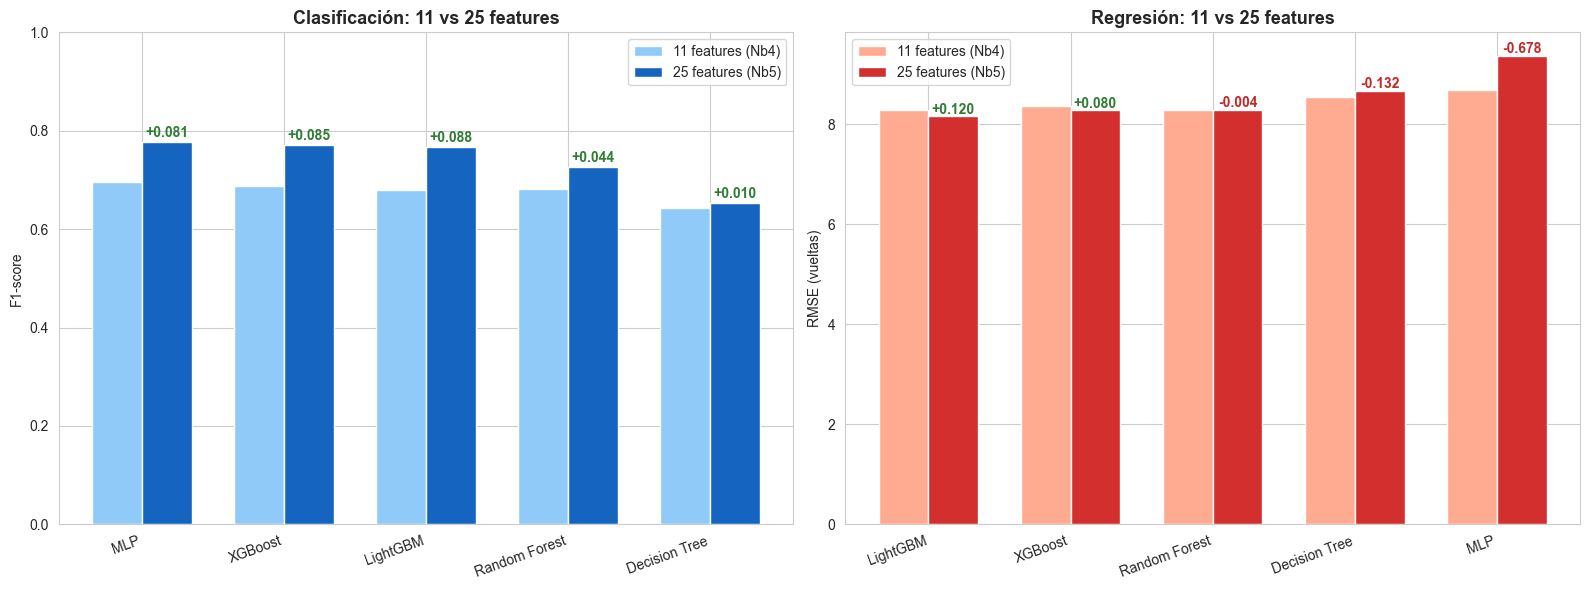

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Clasificación ---
df_c = pd.DataFrame(resultados_clasif_v2).T.sort_values('F1 (25 feat)', ascending=False)
x = np.arange(len(df_c))
w = 0.35
axes[0].bar(x - w/2, df_c['F1 (11 feat)'], w, label='11 features (Nb4)', color='#90CAF9')
axes[0].bar(x + w/2, df_c['F1 (25 feat)'], w, label='25 features (Nb5)', color='#1565C0')
for i, m in enumerate(df_c['Mejora']):
    color = '#2E7D32' if m > 0 else '#C62828'
    axes[0].text(i + w/2, df_c['F1 (25 feat)'].iloc[i] + 0.01, f'{m:+.3f}',
                ha='center', fontsize=10, fontweight='bold', color=color)
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_c.index, rotation=20, ha='right')
axes[0].set_ylabel('F1-score')
axes[0].set_title('Clasificación: 11 vs 25 features', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1)

# --- Regresión ---
df_r = pd.DataFrame(resultados_regres_v2).T.sort_values('RMSE (25 feat)')
x = np.arange(len(df_r))
axes[1].bar(x - w/2, df_r['RMSE (11 feat)'], w, label='11 features (Nb4)', color='#FFAB91')
axes[1].bar(x + w/2, df_r['RMSE (25 feat)'], w, label='25 features (Nb5)', color='#D32F2F')
for i, m in enumerate(df_r['Mejora RMSE']):
    color = '#2E7D32' if m > 0 else '#C62828'
    axes[1].text(i + w/2, df_r['RMSE (25 feat)'].iloc[i] + 0.05, f'{m:+.3f}',
                ha='center', fontsize=10, fontweight='bold', color=color)
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_r.index, rotation=20, ha='right')
axes[1].set_ylabel('RMSE (vueltas)')
axes[1].set_title('Regresión: 11 vs 25 features', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('./datasets/prepared/fig_11_vs_25_features.png', dpi=150, bbox_inches='tight')
plt.show()


## 12. Importancia de variables con el nuevo conjunto

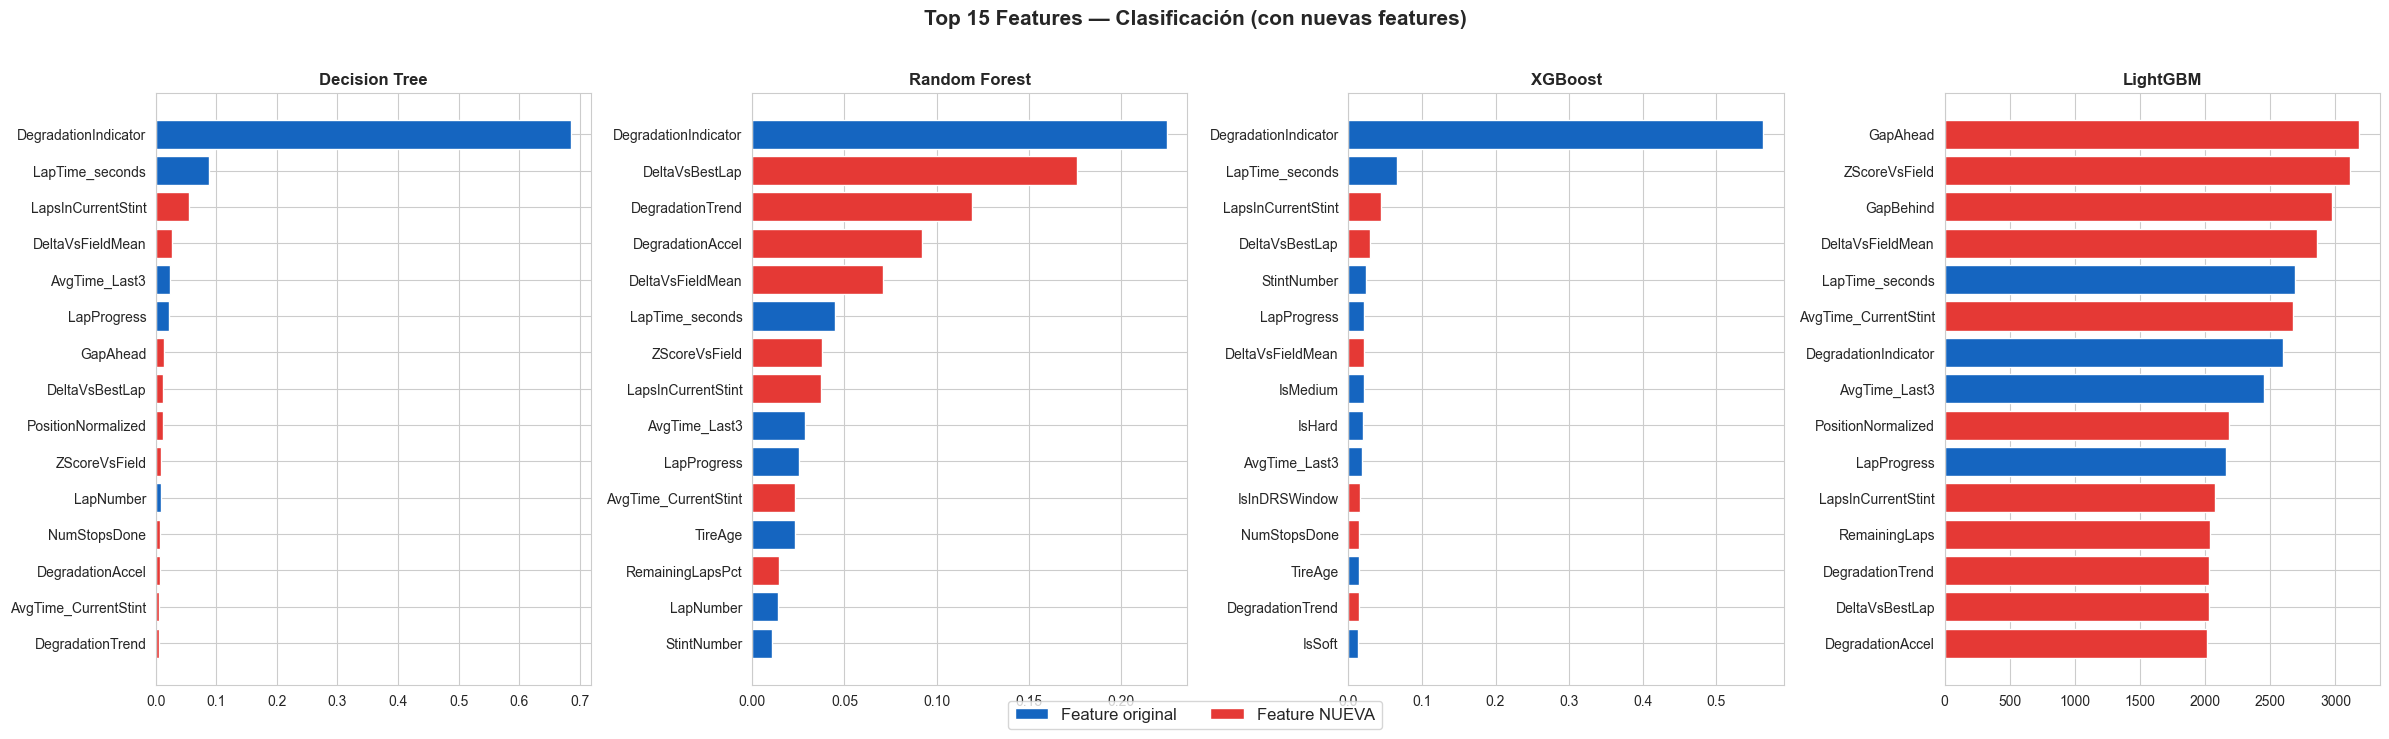

In [23]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 4, figsize=(24, 7))

for idx, nombre in enumerate(['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM']):
    modelo = modelos_clasif[nombre]
    importancias = modelo.feature_importances_
    indices = np.argsort(importancias)[::-1][:15]  # Top 15

    colors = ['#E53935' if features_disponibles[i] in FEATURES_NUEVAS else '#1565C0'
              for i in indices]

    axes[idx].barh(
        [features_disponibles[i] for i in indices],
        importancias[indices],
        color=colors
    )
    axes[idx].set_title(nombre, fontsize=12, fontweight='bold')
    axes[idx].invert_yaxis()

legend_elements = [Patch(facecolor='#1565C0', label='Feature original'),
                   Patch(facecolor='#E53935', label='Feature NUEVA')]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=12,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Top 15 Features — Clasificación (con nuevas features)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./datasets/prepared/fig_feature_importance_v2.png', dpi=150, bbox_inches='tight')
plt.show()


## 13. Persistencia de los datasets con 25 features

Los splits temporales reconstruidos con las 25 features se guardan en disco para reutilización por parte de los notebooks posteriores (notebook 8 — validación por grupos y notebook 9 — análisis SHAP). De este modo, esos notebooks pueden cargar los CSVs directamente sin reejecutar toda la cadena de ingeniería de features.

In [24]:
# Columnas a guardar: metadatos + features + targets
COLS_GUARDAR = (
    ['Season', 'Round', 'EventName', 'EventDate', 'Driver',  # metadatos
     'StopLapNumber', 'LapsUntilNextStop']                    # targets/auxiliares
    + features_disponibles                                    # las 25 features
    + ['target_parada']                                       # target de clasificación
)

def cols_existentes(df_, cols):
    """Devuelve las columnas presentes, sin duplicados."""
    seen = set()
    out = []
    for c in cols:
        if c in df_.columns and c not in seen:
            out.append(c)
            seen.add(c)
    return out

ruta_train_clf = './datasets/prepared/train_clasificacion_avanzado.csv'
ruta_test_clf  = './datasets/prepared/test_clasificacion_avanzado.csv'
ruta_train_reg = './datasets/prepared/train_regresion_avanzado.csv'
ruta_test_reg  = './datasets/prepared/test_regresion_avanzado.csv'

train_c[cols_existentes(train_c, COLS_GUARDAR)].to_csv(ruta_train_clf, index=False)
test_c [cols_existentes(test_c,  COLS_GUARDAR)].to_csv(ruta_test_clf,  index=False)
train_r[cols_existentes(train_r, COLS_GUARDAR)].to_csv(ruta_train_reg, index=False)
test_r [cols_existentes(test_r,  COLS_GUARDAR)].to_csv(ruta_test_reg,  index=False)

# Persistir scalers (útiles si después se quieren reproducir resultados de MLP)
with open('./datasets/prepared/scaler_v2_clasif.pkl', 'wb') as f:
    pickle.dump(scaler_c, f)
with open('./datasets/prepared/scaler_v2_regres.pkl', 'wb') as f:
    pickle.dump(scaler_r, f)

print('✅ Datasets con 25 features persistidos:')
print(f'   {ruta_train_clf}')
print(f'      → {train_c.shape[0]:>6,} filas × {len(cols_existentes(train_c, COLS_GUARDAR))} cols')
print(f'   {ruta_test_clf}')
print(f'      → {test_c.shape[0]:>6,} filas × {len(cols_existentes(test_c, COLS_GUARDAR))} cols')
print(f'   {ruta_train_reg}')
print(f'      → {train_r.shape[0]:>6,} filas × {len(cols_existentes(train_r, COLS_GUARDAR))} cols')
print(f'   {ruta_test_reg}')
print(f'      → {test_r.shape[0]:>6,} filas × {len(cols_existentes(test_r, COLS_GUARDAR))} cols')

n_feat_guardadas = sum(1 for f in features_disponibles if f in train_c.columns)
print(f'\n   Features del modelo en el dataset: {n_feat_guardadas}/{len(features_disponibles)}')
if n_feat_guardadas < len(features_disponibles):
    faltantes = [f for f in features_disponibles if f not in train_c.columns]
    print(f'   ⚠️ Faltantes: {faltantes}')


✅ Datasets con 25 features persistidos:
   ./datasets/prepared/train_clasificacion_avanzado.csv
      → 74,392 filas × 33 cols
   ./datasets/prepared/test_clasificacion_avanzado.csv
      → 18,599 filas × 33 cols
   ./datasets/prepared/train_regresion_avanzado.csv
      → 42,691 filas × 33 cols
   ./datasets/prepared/test_regresion_avanzado.csv
      → 10,673 filas × 33 cols

   Features del modelo en el dataset: 25/25


## 14. Resumen final y exportación de modelos

In [25]:
print('='*70)
print('RESUMEN — INGENIERÍA DE FEATURES AVANZADA')
print('='*70)

print(f'\nFeatures: {len(FEATURES_ORIGINAL)} originales + {len(FEATURES_NUEVAS)} nuevas = {len(features_disponibles)} total')

print(f'\n📊 CLASIFICACIÓN')
print(f'{"─"*60}')
df_c_final = pd.DataFrame(resultados_clasif_v2).T.sort_values('F1 (25 feat)', ascending=False)
for nombre in df_c_final.index:
    r = df_c_final.loc[nombre]
    emoji = '📈' if r['Mejora'] > 0.01 else '➡️'
    print(f'  {emoji} {nombre:20s}  {r["F1 (11 feat)"]:.4f} → {r["F1 (25 feat)"]:.4f} ({r["Mejora"]:+.4f})')

print(f'\n📈 REGRESIÓN')
print(f'{"─"*60}')
df_r_final = pd.DataFrame(resultados_regres_v2).T.sort_values('RMSE (25 feat)')
for nombre in df_r_final.index:
    r = df_r_final.loc[nombre]
    emoji = '📈' if r['Mejora RMSE'] > 0.1 else '➡️'
    print(f'  {emoji} {nombre:20s}  {r["RMSE (11 feat)"]:.3f} → {r["RMSE (25 feat)"]:.3f} ({r["Mejora RMSE"]:+.3f})')

# Guardar resultados como CSV
df_c_final.round(4).to_csv('./datasets/prepared/resultados_clasif_features_avanzadas.csv')
df_r_final.round(4).to_csv('./datasets/prepared/resultados_regres_features_avanzadas.csv')

# Guardar modelos entrenados
for nombre, modelo in modelos_clasif.items():
    fname = f'./datasets/prepared/modelo_v2_clasif_{nombre.lower().replace(" ", "_")}.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(modelo, f)
for nombre, modelo in modelos_regres.items():
    fname = f'./datasets/prepared/modelo_v2_regres_{nombre.lower().replace(" ", "_")}.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(modelo, f)

print(f'\n📁 Archivos guardados en ./datasets/prepared/')
print(f'\n✅ Notebook 5 completado')
print(f'\n🎯 PRÓXIMOS PASOS:')
print(f'   1. Notebook 6: Modelos adicionales (SVM, regresión logística/Ridge)')
print(f'   2. Notebook 8: Validación por grupos (GroupKFold)')
print(f'   3. Notebook 9: Análisis SHAP de interpretabilidad')


RESUMEN — INGENIERÍA DE FEATURES AVANZADA

Features: 11 originales + 14 nuevas = 25 total

📊 CLASIFICACIÓN
────────────────────────────────────────────────────────────
  📈 MLP                   0.6958 → 0.7767 (+0.0809)
  📈 XGBoost               0.6873 → 0.7720 (+0.0847)
  📈 LightGBM              0.6787 → 0.7662 (+0.0875)
  📈 Random Forest         0.6825 → 0.7262 (+0.0437)
  ➡️ Decision Tree         0.6438 → 0.6537 (+0.0099)

📈 REGRESIÓN
────────────────────────────────────────────────────────────
  📈 LightGBM              8.284 → 8.164 (+0.120)
  ➡️ XGBoost               8.364 → 8.283 (+0.080)
  ➡️ Random Forest         8.290 → 8.294 (-0.004)
  ➡️ Decision Tree         8.540 → 8.672 (-0.132)
  ➡️ MLP                   8.692 → 9.370 (-0.678)

📁 Archivos guardados en ./datasets/prepared/

✅ Notebook 5 completado

🎯 PRÓXIMOS PASOS:
   1. Notebook 6: Modelos adicionales (SVM, regresión logística/Ridge)
   2. Notebook 8: Validación por grupos (GroupKFold)
   3. Notebook 9: Análisis SHAP de